### 매뉴얼 - 다중 선형 회귀 (Multiple Linear Regression)

본 노트북은 AI 컴패니언 의존도(정서적 애착도 `emotional_attachment_score`)를 다중 수치형 피처 및 원-핫 인코딩된 범주형 피처들을 포함하여 다중 선형 회귀 모델로 예측하고 분석한다.

In [1]:
import os
import platform
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
data = pd.read_csv('data/ai_companion_dependency_dataset.csv')
print(f"원본 데이터 로드 완료: {data.shape}")

원본 데이터 로드 완료: (1000, 30)


In [2]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from IPython.display import display

# ===========================================================================================================
# 1. 데이터 필터링-행 :: (청소년, 넓게는 청년층과 AI에 대한 심리적 문제가 대상이므로, 특정 연령대와 특정 이용목적만을 남긴다.)
# ===========================================================================================================

"""
age: 15세 ~ 24세 (청소년층 / 청년층)
primary_use_cases : Companionship, Entertainment, Therapy-Substitute
"""
target_col = ['Companionship', 'Entertainment', 'Therapy-Substitute']

df_filtered = data[
    (data['age'] >= 15) & (data['age'] <= 24) &
    (data['primary_use_case'].isin(target_col))
].copy()


# ===========================================================================================================
# 2. 데이터 필터링-열 :: 수치형 피처 + 보류했던 범주형 3개 피처만 선택
# ===========================================================================================================

"""
[제외 피쳐 목록]
user_id, gender, country_region, ai_chatbot_platform, prefers_ai_over_humans,
academic_or_work_performance_change, dependency_risk_label,
education_level, income_level, primary_use_case, therapy_attendance

[보류에서 -> 분석 대상으로 추가된 피쳐 3종]
- occupation_status (직업 상태)
- relationship_status (연애/대인 관계 상태)
- living_situation (주거 형태)
"""

# 포함할 분석 대상 피쳐 선택 (수치형 15개 + 보류 피처 3개 + 타깃 1개 = 총 19개)
selected_features = [
    # 기본 인구통계 및 [보류 해제 피처 3개]
    'age',
    'occupation_status',        # [추가] 직업 상태
    'relationship_status',      # [추가] 연애/결혼 상태
    'living_situation',         # [추가] 주거 형태
    
    # 일상 및 디지털 활동 시간 (수치형)
    'daily_ai_chat_hours',
    'human_social_interaction_hours',
    'social_media_hours_daily',
    'screen_time_total_hours',
    
    # 사회적 관계 (수치형)
    'number_of_close_friends',
    'real_relationship_satisfaction',
    
    # 생활 습관 및 수면 (수치형)
    'sleep_hours',
    'sleep_quality_score',
    'exercise_hours_weekly',
    
    # 심리적 척도 (수치형)
    'loneliness_score',
    'anxiety_score',
    'depression_score',
    'stress_score',
    'self_esteem_score',
    
    # 종속 변수 (Target)
    'emotional_attachment_score'
]

# 1차 필터링 데이터프레임 생성
df = df_filtered[selected_features].reset_index(drop=True)

print(f"원본 데이터 크기: {data.shape}")
print(f"필터링 데이터 크기: {df.shape}")


# ===========================================================================================================
# 3. 오직 [보류 피처 3개]만 원-핫 인코딩 수행 (OneHotEncoder)
# ===========================================================================================================

# 1) 원-핫 인코딩할 3개 피처 지정
categorical_features = ['occupation_status', 'relationship_status', 'living_situation']

# 2) 순수 수치형 피처 목록
numeric_features = [
    'age', 'daily_ai_chat_hours', 'human_social_interaction_hours', 
    'social_media_hours_daily', 'screen_time_total_hours', 'number_of_close_friends', 
    'real_relationship_satisfaction', 'sleep_hours', 'sleep_quality_score', 
    'exercise_hours_weekly', 'loneliness_score', 'anxiety_score', 
    'depression_score', 'stress_score', 'self_esteem_score'
]

target_feature = 'emotional_attachment_score'

# 3) OneHotEncoder로 3개 피처만 변환 (다중공선성 방지 drop='first')
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(df[categorical_features])
encoded_columns = ohe.get_feature_names_out(categorical_features)

df_encoded_cats = pd.DataFrame(encoded_array, columns=encoded_columns)

# 4) 수치형 피처 + 인코딩된 3개 범주형 피처 + 타깃 결합
df_final = pd.concat([df[numeric_features], df_encoded_cats, df[[target_feature]]], axis=1)

# 5) 독립변수 X와 종속변수 y 분리
X = df_final.drop(columns=[target_feature])
y = df_final[target_feature]

# ===========================================================================================================
# 4. 최종 데이터 확인
# ===========================================================================================================
print("\n" + "="*70)
print(f"최종 전처리 완료 데이터 크기: {df_final.shape}")
print(f"독립변수(X) 피처 개수: {X.shape[1]}개 | 종속변수(y) 크기: {y.shape[0]}개")
print("="*70)

print("\n--- [추가된 3개 피처의 더미 컬럼 목록] ---")
print(encoded_columns.tolist())

print("\n--- [최종 데이터 상위 5개 행 (X)] ---")
display(X.head())

원본 데이터 크기: (1000, 30)
필터링 데이터 크기: (196, 19)

최종 전처리 완료 데이터 크기: (196, 26)
독립변수(X) 피처 개수: 25개 | 종속변수(y) 크기: 196개

--- [추가된 3개 피처의 더미 컬럼 목록] ---
['occupation_status_Employed Part-Time', 'occupation_status_Freelancer', 'occupation_status_Student', 'occupation_status_Unemployed', 'relationship_status_In a Relationship', 'relationship_status_Married', 'relationship_status_Single', 'living_situation_With Family', 'living_situation_With Partner', 'living_situation_With Roommates']

--- [최종 데이터 상위 5개 행 (X)] ---


,age,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,...,occupation_status_Employed Part-Time,occupation_status_Freelancer,occupation_status_Student,occupation_status_Unemployed,relationship_status_In a Relationship,relationship_status_Married,relationship_status_Single,living_situation_With Family,living_situation_With Partner,living_situation_With Roommates
0,22,0.94,5.49,2.46,5.10,4,5.5,5.8,7.1,2.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,17,0.00,4.96,1.86,5.42,4,8.8,9.3,7.7,6.1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,16,1.47,5.18,2.70,6.23,6,3.8,8.1,5.2,5.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,24,0.00,4.91,0.65,1.79,7,10.0,7.1,7.9,4.9,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,17,0.00,4.43,0.52,3.03,3,8.4,9.2,9.5,4.1,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


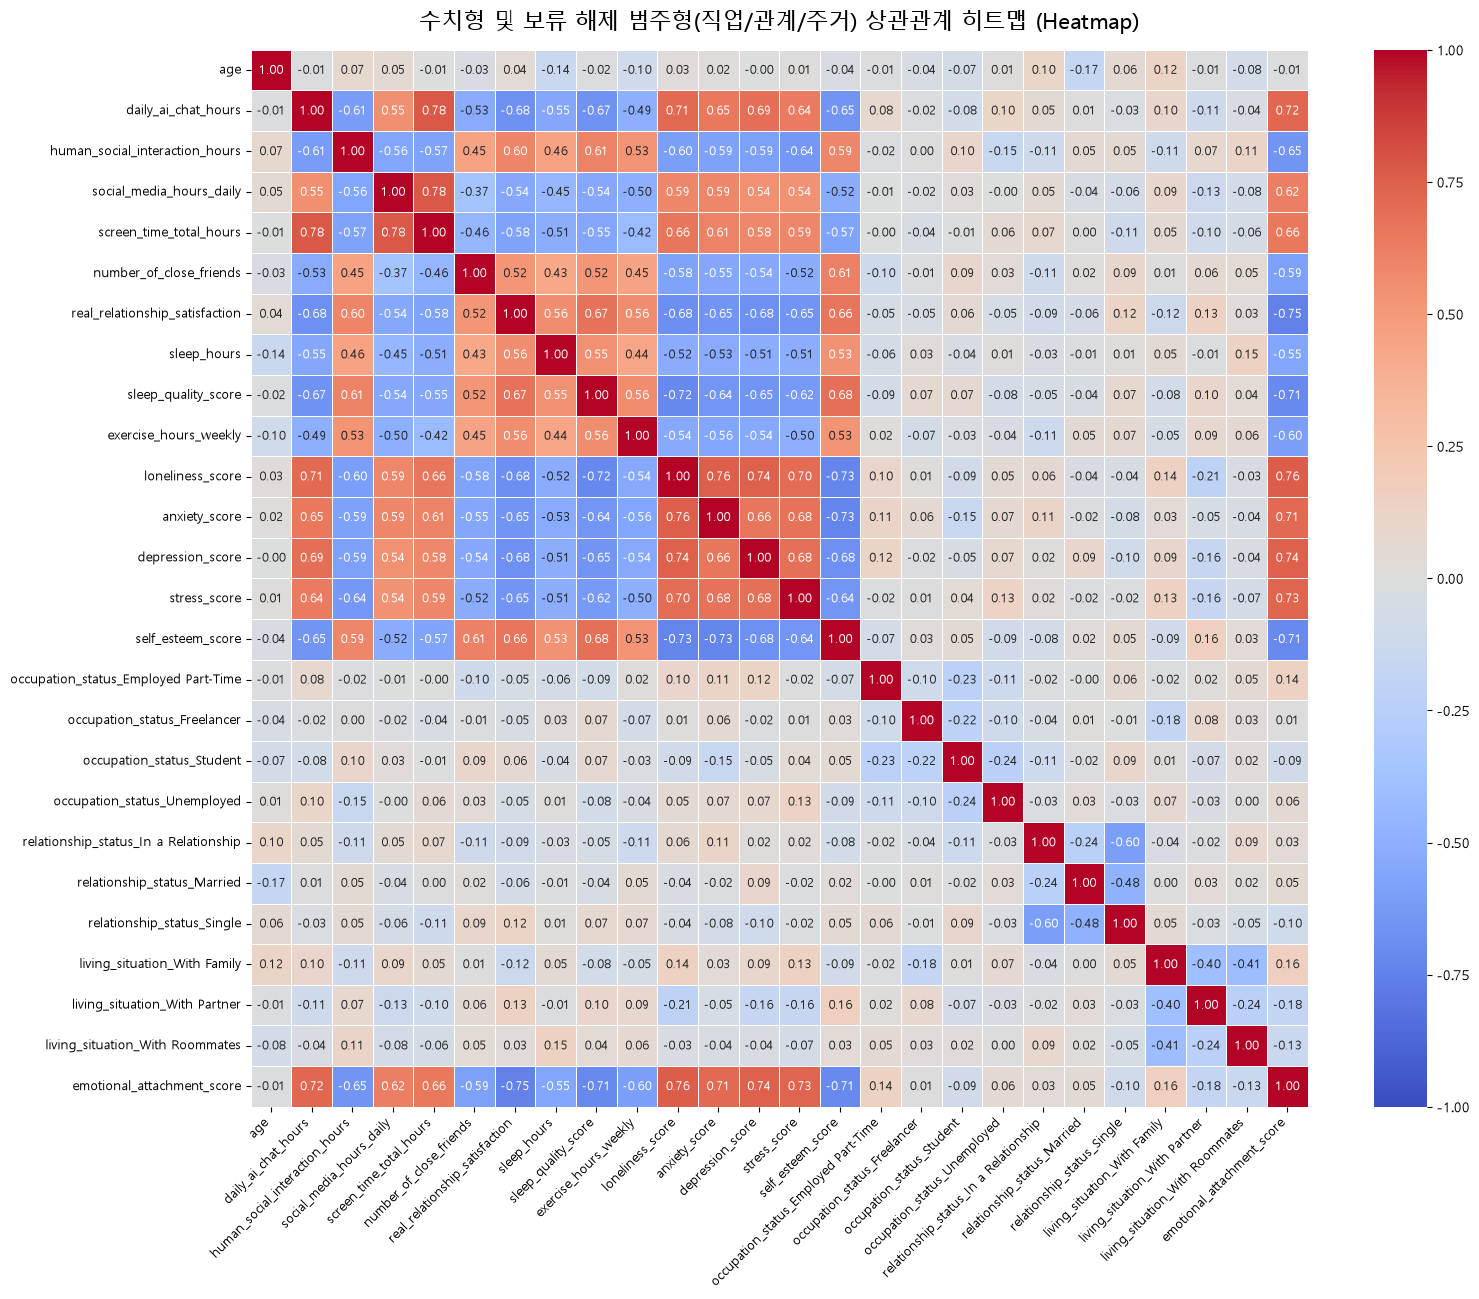

In [3]:
# ===========================================================================================================
# EDA: 상관관계 히트맵 (수치형 피처 + 보류 해제 범주형 3종 피처)
# ===========================================================================================================

# 수치형 피처 + 보류 해제 범주형 3종 더미 변수가 포함된 df_final 기준으로 상관계수 행렬 계산
corr_matrix = df_final.corr()

# 히트맵 시각화
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9}
)
plt.title('수치형 및 보류 해제 범주형(직업/관계/주거) 상관관계 히트맵 (Heatmap)', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

--- [정서적 애착도(Target)와 상관관계 상위 6개 피처] ---
  1위: loneliness_score                    (상관계수 r = +0.760)
  2위: real_relationship_satisfaction      (상관계수 r = -0.747)
  3위: depression_score                    (상관계수 r = +0.743)
  4위: stress_score                        (상관계수 r = +0.728)
  5위: daily_ai_chat_hours                 (상관계수 r = +0.719)
  6위: anxiety_score                       (상관계수 r = +0.712)


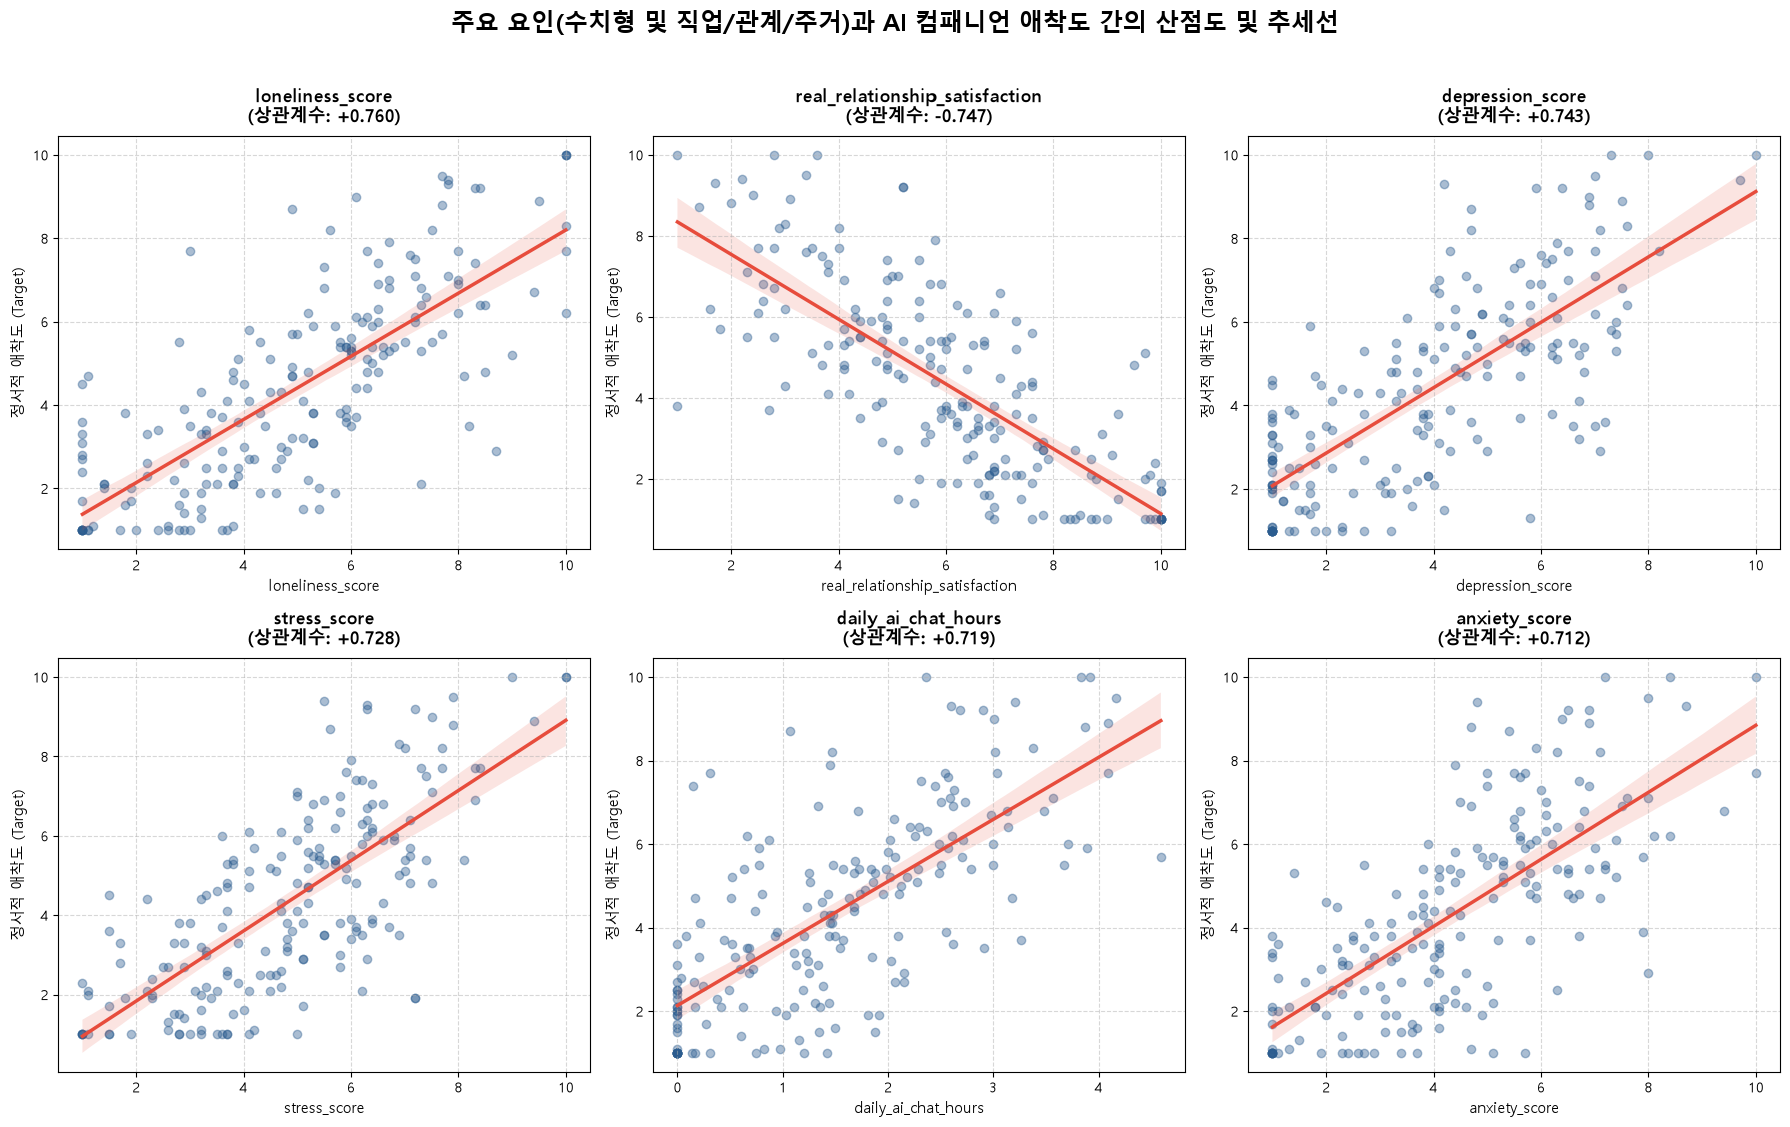

In [4]:
# ===========================================================================================================
# EDA: 종속 변수(Target) vs 주요 요인 간의 산점도 및 선형 추세선 시각화
# ===========================================================================================================

# 1. 타깃(emotional_attachment_score)과 상관관계 절댓값이 가장 큰 상위 6개 피처 자동 추출
corr_series = df_final.corr()['emotional_attachment_score'].drop('emotional_attachment_score')
top_6_features = corr_series.abs().sort_values(ascending=False).head(6).index.tolist()

print("--- [정서적 애착도(Target)와 상관관계 상위 6개 피처] ---")
for rank, feat in enumerate(top_6_features, 1):
    print(f"  {rank}위: {feat:<35} (상관계수 r = {corr_series[feat]:+.3f})")

# 2. 2행 3열 서브플롯(Subplots) 생성
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    corr_val = corr_series[feature]
    
    # seaborn의 regplot으로 산점도 + 단순 선형 회귀 추세선 함께 시각화
    sns.regplot(
        data=df_final,
        x=feature,
        y='emotional_attachment_score',
        ax=axes[idx],
        scatter_kws={'alpha': 0.4, 'color': '#2b5c8f'}, # 점 투명도 및 색상
        line_kws={'color': '#e74c3c', 'linewidth': 2.5}  # 회귀선 색상 및 두께
    )
    
    # 그래프 서식 설정
    axes[idx].set_title(f'{feature}\n(상관계수: {corr_val:+.3f})', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('정서적 애착도 (Target)', fontsize=11)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('주요 요인(수치형 및 직업/관계/주거)과 AI 컴패니언 애착도 간의 산점도 및 추세선', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ===========================================================================================================
# 5. 다중공선성(VIF) 확인 & Train / Test 분할
# ===========================================================================================================

# 자체 VIF 계산 함수 구현 (LinearRegression R^2 이용)
def calculate_vif(df_features):
    vif_list = []
    cols = df_features.columns
    for col in cols:
        y_sub = df_features[col]
        X_sub = df_features.drop(columns=[col])
        r2_sub = LinearRegression().fit(X_sub, y_sub).score(X_sub, y_sub)
        vif = 1.0 / (1.0 - r2_sub) if r2_sub < 1.0 else np.inf
        vif_list.append(vif)
    return pd.DataFrame({'Feature': cols, 'VIF': vif_list})

vif_df = calculate_vif(X)
print("--- [독립변수 VIF (분산팽창지수)] ---")
print(vif_df.sort_values(by='VIF', ascending=False).to_string(index=False))

# Train/Test 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n훈련 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")

--- [독립변수 VIF (분산팽창지수)] ---
                              Feature      VIF
              screen_time_total_hours 5.236000
           relationship_status_Single 4.973460
                  daily_ai_chat_hours 4.419570
                     loneliness_score 4.204714
relationship_status_In a Relationship 4.103236
                        anxiety_score 3.483324
             social_media_hours_daily 3.453778
          relationship_status_Married 3.310162
                    self_esteem_score 3.181930
                     depression_score 3.172031
                  sleep_quality_score 2.952341
                         stress_score 2.948132
       real_relationship_satisfaction 2.929280
       human_social_interaction_hours 2.386209
         living_situation_With Family 2.027503
                          sleep_hours 2.002203
                exercise_hours_weekly 1.972445
              number_of_close_friends 1.895492
      living_situation_With Roommates 1.745168
        living_situation_With Pa


--- [다중 선형 회귀 모델 평가 결과] ---
[Train 데이터] MSE: 1.1305 | RMSE: 1.0632 | MAE: 0.8403 | R²: 0.7832
[Test  데이터] MSE: 1.7544 | RMSE: 1.3245 | MAE: 1.1082 | R²: 0.7336 | Adj R²: 0.2578


C:\Users\human-07\AppData\Local\Temp\ipykernel_6684\4172315243.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='vlag')


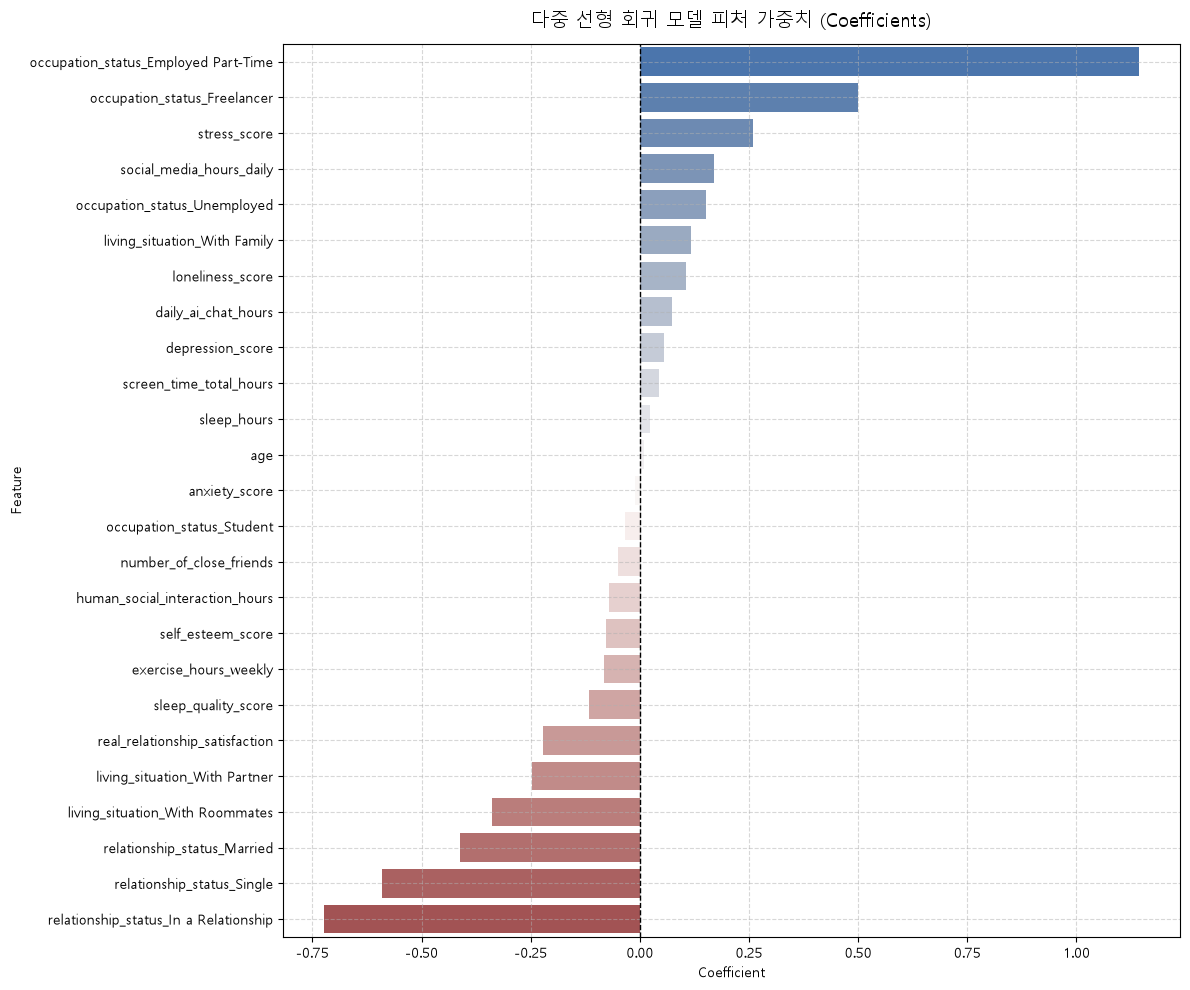

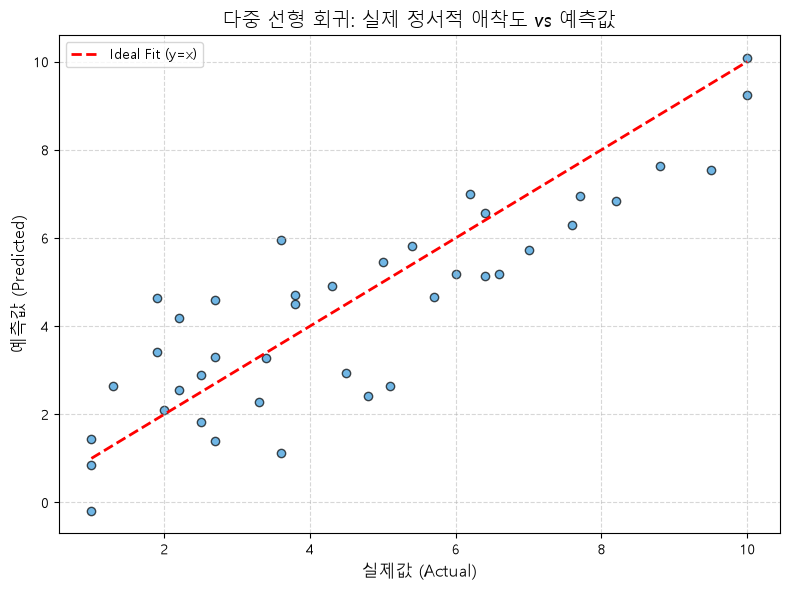

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===========================================================================================================
# 6. 모델 선택, 7. 학습 및 8. 평가
# ===========================================================================================================
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 예측
y_train_pred = mlr_model.predict(X_train)
y_test_pred = mlr_model.predict(X_test)

# 성능 평가
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 수정된 R² (Adjusted R²)
n_test = len(y_test)
p_test = X_test.shape[1]
adj_test_r2 = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p_test - 1)

print("\n--- [다중 선형 회귀 모델 평가 결과] ---")
print(f"[Train 데이터] MSE: {train_mse:.4f} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}")
print(f"[Test  데이터] MSE: {test_mse:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f} | Adj R²: {adj_test_r2:.4f}")

# 회귀 계수(Coefficients) 시각화 (새로 추가된 더미 변수 포함 전체 피처)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='vlag')
plt.title('다중 선형 회귀 모델 피처 가중치 (Coefficients)', fontsize=14, pad=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 실제값 vs 예측값 산점도 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='#3498db', alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Ideal Fit (y=x)')
plt.title('다중 선형 회귀: 실제 정서적 애착도 vs 예측값', fontsize=14)
plt.xlabel('실제값 (Actual)', fontsize=12)
plt.ylabel('예측값 (Predicted)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()